In [ ]:
# ===============================
# BipedalWalkerHardcore-v3 SAC
# Train + Save Best Policy as GIF
# ===============================

import os
import gymnasium as gym
import numpy as np
import imageio
import torch

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# ===============================
# CONFIG
# ===============================

ENV_ID = "BipedalWalkerHardcore-v3"
TOTAL_TIMESTEPS = 10_000_000
N_ENVS = 8
SEED = 42

LOG_DIR = "./logs"
MODEL_DIR = "./models"
GIF_PATH = "./best_policy.gif"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ===============================
# ENV FACTORIES
# ===============================

def make_env(env_id, seed):
    def _init():
        env = gym.make(env_id)
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

# ===============================
# TRAINING ENVS (SubprocVecEnv for parallelization)
# ===============================
train_env = SubprocVecEnv([make_env(ENV_ID, SEED + i) for i in range(N_ENVS)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,
    norm_reward=True,
    clip_obs=10.0,
    clip_reward=10.0
)

# ===============================
# EVAL ENVS (share normalization with training)
# ===============================

eval_env = SubprocVecEnv([make_env(ENV_ID, 1000)])
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False  # Don't update running stats during eval
)

# ===============================
# CALLBACK (SAVE BEST + SYNC STATS)
# ===============================

class SyncVecNormalizeCallback(EvalCallback):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def _on_step(self) -> bool:
        # Sync eval_env normalization stats with training env
        if self.eval_env is not None:
            self.eval_env.obs_rms = self.training_env.obs_rms
            self.eval_env.ret_rms = self.training_env.ret_rms
        return super()._on_step()

eval_callback = SyncVecNormalizeCallback(
    eval_env,
    best_model_save_path=MODEL_DIR,
    log_path=LOG_DIR,
    eval_freq=50_000 // N_ENVS,  # Adjusted for parallel envs
    deterministic=True,
    render=False,
    n_eval_episodes=10
)

# ===============================
# MODEL (Improved Hyperparameters)
# ===============================

policy_kwargs = dict(
    net_arch=[256, 256],  # Larger networks for complex task
    activation_fn=torch.nn.ReLU
)

model = SAC(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    buffer_size=1_000_000,  # Reduced for memory efficiency
    batch_size=256,
    tau=0.02,  # Faster target network updates
    gamma=0.99,
    train_freq=(1, "episode"),  # Train after each episode
    gradient_steps=-1,  # As many gradient steps as steps in episode
    ent_coef="auto_0.1",  # Initial entropy coefficient
    target_entropy="auto",
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=1,
    tensorboard_log=LOG_DIR,
    use_sde=True,  # State-dependent exploration
    sde_sample_freq=4  # Resample noise every 4 steps
)

# ===============================
# TRAIN
# ===============================

print("Starting training...")
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    progress_bar=True
)

# ===============================
# SAVE NORMALIZATION STATS
# ===============================

train_env.save(os.path.join(MODEL_DIR, "vecnormalize.pkl"))
print(f"✅ Normalization stats saved to: {MODEL_DIR}/vecnormalize.pkl")

# ===============================
# LOAD BEST MODEL
# ===============================

best_model = SAC.load(os.path.join(MODEL_DIR, "best_model"))
print(f"✅ Best model loaded from: {MODEL_DIR}/best_model")

# ===============================
# RENDER BEST POLICY → GIF
# ===============================

render_env = gym.make(ENV_ID, render_mode="rgb_array")
render_env = Monitor(render_env)

# Load normalization stats
vec_normalize = VecNormalize.load(
    os.path.join(MODEL_DIR, "vecnormalize.pkl"),
    SubprocVecEnv([lambda: render_env])
)
vec_normalize.training = False
vec_normalize.norm_reward = False

obs = vec_normalize.reset()
frames = []

print("Rendering GIF...")
for step in range(2000):
    action, _ = best_model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_normalize.step(action)
    
    # Get frame from the underlying env
    frame = render_env.render()
    frames.append(frame)
    
    if done:
        print(f"Episode finished at step {step}")
        break

vec_normalize.close()

# ===============================
# SAVE GIF
# ===============================

if frames:
    imageio.mimsave(GIF_PATH, frames, fps=30)
    print(f"✅ GIF saved to: {GIF_PATH} ({len(frames)} frames)")
else:
    print("⚠️ No frames captured!")

Using cpu device
Logging to ./logs\SAC_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 66       |
|    ep_rew_mean     | -109     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 477      |
|    time_elapsed    | 1        |
|    total_timesteps | 656      |
| train/             |          |
|    actor_loss      | -5.46    |
|    critic_loss     | 0.242    |
|    ent_coef        | 0.98     |
|    ent_coef_loss   | -0.137   |
|    learning_rate   | 0.0003   |
|    n_updates       | 69       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 70.6     |
|    ep_rew_mean     | -108     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 439      |
|    time_elapsed    | 3        |
|    total_timesteps | 1432     |
| train/             |          |
|    actor_loss      | -6.32    |
|    cr

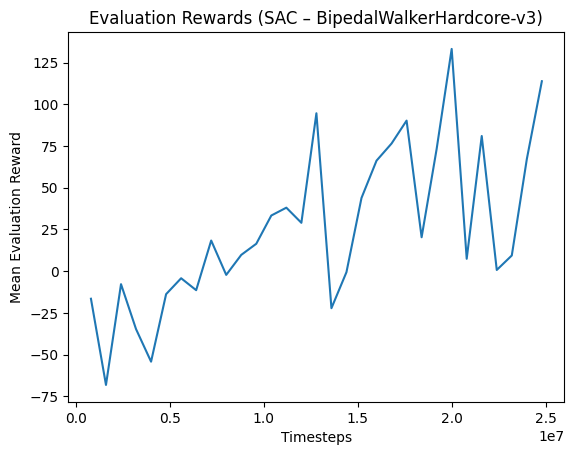

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

LOG_DIR = "./logs"
EVAL_FILE = os.path.join(LOG_DIR, "evaluations.npz")

# -------------------------------
# Load evaluation data
# -------------------------------
if not os.path.exists(EVAL_FILE):
    raise FileNotFoundError(
        f"{EVAL_FILE} not found.\n"
        "Make sure EvalCallback was used and training ran at least once."
    )

data = np.load(EVAL_FILE)

timesteps = data["timesteps"]
results = data["results"]

# Mean reward per evaluation
mean_rewards = results.mean(axis=1)

# -------------------------------
# Plot
# -------------------------------
plt.figure()
plt.plot(timesteps, mean_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Mean Evaluation Reward")
plt.title("Evaluation Rewards (SAC – BipedalWalkerHardcore-v3)")
plt.show()


In [14]:
def make_render_env():
    def _init():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        env = Monitor(env)
        env.reset(seed=123)
        return env
    return _init

render_env = DummyVecEnv([make_render_env()])
render_env = VecNormalize.load(
    os.path.join(MODEL_DIR, "vecnormalize.pkl"),
    render_env
)
render_env.training = False
render_env.norm_reward = False

best_model = SAC.load(
    os.path.join(MODEL_DIR, "best_model"),
    env=render_env
)


obs = render_env.reset()
frames = []

prev_action = np.zeros((1,) + render_env.action_space.shape)

for _ in range(2000):
    action, _ = best_model.predict(obs, deterministic=True)

    action = 0.9 * prev_action + 0.1 * action
    prev_action = action

    obs, rewards, dones, infos = render_env.step(action)

    frame = render_env.render()
    frames.append(frame)

    if dones[0]:
        break

render_env.close()
imageio.mimsave(GIF_PATH, frames, fps=30)

print(f"\n✅ GIF saved to: {GIF_PATH}")



✅ GIF saved to: ./best_policy.gif
